In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.colors as colors

plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings("ignore")

In [2]:
cd C:\Users\tr432\Downloads\filter_GutLungAxis_Week2

C:\Users\tr432\Downloads\filter_GutLungAxis_Week2


In [3]:
import pandas as pd

df_tax = pd.read_csv("gg2_genus_table.tsv", sep='\t', skiprows=1, index_col="#OTU ID")
df_tax["Total"] = df_tax.sum(axis=1)
df_tax = df_tax.sort_values("Total", ascending=False)

meta = pd.read_csv("RUN45_Metadata_GutLungAxis.txt", sep='\t')  ## csv일땐 sep='\t' 지워도 됨

print(df_tax.head(3))
print(meta.head(3))

                                                     C01-2w   C02-2w  C03-2w  \
#OTU ID                                                                        
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac...    194.0    203.0    53.0   
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__B...  22632.0  17792.0  9379.0   
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lact...  17030.0  10938.0  9763.0   

                                                     C09-2w   C10-2w   C11-2w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonadota;c__Gammaproteobac...    152.0    376.0    182.0   
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__B...  32189.0  32124.0  20338.0   
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lact...  20514.0   2460.0   6757.0   

                                                     V01-2w   V02-2w   V03-2w  \
#OTU ID                                                                         
d__Bacteria;p__Pseudomonadota;c

In [4]:
mapping = dict(zip(meta["#SampleID"].astype(str), meta["Group"].astype(str)))

df_tax2 = df_tax.copy()
df_tax2.columns = [mapping.get(c, None) for c in df_tax.columns[0:]]

df_tax2 = df_tax2.loc[:, [c for c in df_tax2.columns if c is not None]]

grouped = df_tax2.set_index(df_tax2.index).T.groupby(level=0).mean().T

grouped["Total"] = df_tax["Total"]

grouped

,Control,VNAM,Total
#OTU ID,,,
d__Bacteria;p__Pseudomonadota;c__Gammaproteobacteria;o__Enterobacterales_737866;f__Enterobacteriaceae_A_725029;__,193.333333,60667.5,607835.0
d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Phocaeicola_A,22409.000000,125.4,135708.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Lactobacillaceae;g__Ligilactobacillus,11243.666667,5115.1,118613.0
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Lachnospirales;f__Lachnospiraceae;__,10528.333333,6.4,63234.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lactobacillales;f__Lactobacillaceae;g__Lactobacillus,6503.500000,12.3,39144.0
...,...,...,...
d__Bacteria;p__Bacillota_A_368345;c__Clostridia_258483;o__Acetivibrionales;f__DSM-27016;g__Ruminiclostridium,0.333333,0.0,2.0
d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__RF39;f__UBA660;g__UMGS1449,0.333333,0.0,2.0
d__Bacteria;p__Actinomycetota;c__Actinomycetes;o__Actinomycetales;f__Beutenbergiaceae;g__Ruania,0.000000,0.2,2.0


In [5]:
for col in grouped.columns:
    print(col, sum(grouped[col]))

Control 102777.66666666667
VNAM 69689.5
Total 1313561.0


In [6]:
grouped.reset_index(inplace=True)
grouped

#grouped.to_csv("rel_gg2_genus_table_grouped.tsv", sep='\t', index=False)

,#OTU ID,Control,VNAM,Total
0,d__Bacteria;p__Pseudomonadota;c__Gammaproteoba...,193.333333,60667.5,607835.0
1,d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__...,22409.000000,125.4,135708.0
2,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,11243.666667,5115.1,118613.0
3,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,10528.333333,6.4,63234.0
4,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__Lac...,6503.500000,12.3,39144.0
...,...,...,...,...
258,d__Bacteria;p__Bacillota_A_368345;c__Clostridi...,0.333333,0.0,2.0
259,d__Bacteria;p__Bacillota_I;c__Bacilli_A;o__RF3...,0.333333,0.0,2.0
260,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,0.000000,0.2,2.0
261,d__Bacteria;p__Actinomycetota;c__Actinomycetes...,0.000000,0.2,2.0


In [7]:
new_cols = grouped['#OTU ID'].str.split(';', expand=True)
new_cols.columns = ['Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus']

df = pd.concat([new_cols, grouped], axis=1)
df = df.drop(columns=['#OTU ID'])

## 원하는 taxa level + 그룹명만 가져옴
cols = ['Phylum', 'Family', 'Genus'] + df.columns[6:].tolist()
df = df[cols]

df = df.replace('__', '_', regex=True)

df

,Phylum,Family,Genus,Control,VNAM,Total
0,p_Pseudomonadota,f_Enterobacteriaceae_A_725029,_,193.333333,60667.5,607835.0
1,p_Bacteroidota,f_Bacteroidaceae,g_Phocaeicola_A,22409.000000,125.4,135708.0
2,p_Bacillota_I,f_Lactobacillaceae,g_Ligilactobacillus,11243.666667,5115.1,118613.0
3,p_Bacillota_A_368345,f_Lachnospiraceae,_,10528.333333,6.4,63234.0
4,p_Bacillota_I,f_Lactobacillaceae,g_Lactobacillus,6503.500000,12.3,39144.0
...,...,...,...,...,...,...
258,p_Bacillota_A_368345,f_DSM-27016,g_Ruminiclostridium,0.333333,0.0,2.0
259,p_Bacillota_I,f_UBA660,g_UMGS1449,0.333333,0.0,2.0
260,p_Actinomycetota,f_Beutenbergiaceae,g_Ruania,0.000000,0.2,2.0
261,p_Actinomycetota,f_Streptomycetaceae_400641,g_Streptomyces_400150,0.000000,0.2,2.0


In [8]:
df[df['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,Control,VNAM,Total
6,p_Bacteroidota,f_Muribaculaceae,g_Amulumruptor,2276.166667,7.2,13729.0
42,p_Bacteroidota,f_Muribaculaceae,g_Lepagella,484.666667,0.5,2913.0
212,p_Bacteroidota,f_Muribaculaceae,g_Paramuribaculum,2.500000,0.0,15.0
240,p_Bacteroidota,f_Muribaculaceae,_,0.666667,0.0,4.0


In [9]:
## Muribaculaceae인 행 선택
mask = df['Family'] == 'f_Muribaculaceae'
df2 = df.copy()

## Muribaculaceae인데 Genus가 "_" 인 경우 → g_unclassified 로 변경
df2.loc[mask & (df2['Genus'] == '_'), 'Genus'] = 'g_unclassified'

## Muribaculaceae인 모든 행에 대해
# Genus 를 "Family명; Genus명" 형식으로 변경
df2.loc[mask, 'Genus'] = df2.loc[mask, 'Family'] + '; ' + df2.loc[mask, 'Genus']

df2

,Phylum,Family,Genus,Control,VNAM,Total
0,p_Pseudomonadota,f_Enterobacteriaceae_A_725029,_,193.333333,60667.5,607835.0
1,p_Bacteroidota,f_Bacteroidaceae,g_Phocaeicola_A,22409.000000,125.4,135708.0
2,p_Bacillota_I,f_Lactobacillaceae,g_Ligilactobacillus,11243.666667,5115.1,118613.0
3,p_Bacillota_A_368345,f_Lachnospiraceae,_,10528.333333,6.4,63234.0
4,p_Bacillota_I,f_Lactobacillaceae,g_Lactobacillus,6503.500000,12.3,39144.0
...,...,...,...,...,...,...
258,p_Bacillota_A_368345,f_DSM-27016,g_Ruminiclostridium,0.333333,0.0,2.0
259,p_Bacillota_I,f_UBA660,g_UMGS1449,0.333333,0.0,2.0
260,p_Actinomycetota,f_Beutenbergiaceae,g_Ruania,0.000000,0.2,2.0
261,p_Actinomycetota,f_Streptomycetaceae_400641,g_Streptomyces_400150,0.000000,0.2,2.0


In [10]:
df2[df2['Family'] == 'f_Muribaculaceae']

,Phylum,Family,Genus,Control,VNAM,Total
6,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2276.166667,7.2,13729.0
42,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_Lepagella,484.666667,0.5,2913.0
212,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_Paramuribaculum,2.500000,0.0,15.0
240,p_Bacteroidota,f_Muribaculaceae,f_Muribaculaceae; g_unclassified,0.666667,0.0,4.0


In [11]:
df3 = df2.copy()
df3['Phylum'] = df2['Phylum'].str.replace(r'^p_', '', regex=True)
df3['Family'] = df2['Family'].str.replace(r'^f_', '', regex=True)
df3['Genus']  = df2['Genus'] .str.replace(r'^g_', '', regex=True)

df3

,Phylum,Family,Genus,Control,VNAM,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,_,193.333333,60667.5,607835.0
1,Bacteroidota,Bacteroidaceae,Phocaeicola_A,22409.000000,125.4,135708.0
2,Bacillota_I,Lactobacillaceae,Ligilactobacillus,11243.666667,5115.1,118613.0
3,Bacillota_A_368345,Lachnospiraceae,_,10528.333333,6.4,63234.0
4,Bacillota_I,Lactobacillaceae,Lactobacillus,6503.500000,12.3,39144.0
...,...,...,...,...,...,...
258,Bacillota_A_368345,DSM-27016,Ruminiclostridium,0.333333,0.0,2.0
259,Bacillota_I,UBA660,UMGS1449,0.333333,0.0,2.0
260,Actinomycetota,Beutenbergiaceae,Ruania,0.000000,0.2,2.0
261,Actinomycetota,Streptomycetaceae_400641,Streptomyces_400150,0.000000,0.2,2.0


In [12]:
df3[df3['Family'] == 'Muribaculaceae']

,Phylum,Family,Genus,Control,VNAM,Total
6,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2276.166667,7.2,13729.0
42,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Lepagella,484.666667,0.5,2913.0
212,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Paramuribaculum,2.500000,0.0,15.0
240,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_unclassified,0.666667,0.0,4.0


In [13]:
df4 = df3.copy()

df4.head(25)

,Phylum,Family,Genus,Control,VNAM,Total
0,Pseudomonadota,Enterobacteriaceae_A_725029,_,193.333333,60667.5,607835.0
1,Bacteroidota,Bacteroidaceae,Phocaeicola_A,22409.000000,125.4,135708.0
2,Bacillota_I,Lactobacillaceae,Ligilactobacillus,11243.666667,5115.1,118613.0
3,Bacillota_A_368345,Lachnospiraceae,_,10528.333333,6.4,63234.0
4,Bacillota_I,Lactobacillaceae,Lactobacillus,6503.500000,12.3,39144.0
5,Bacillota_A_368345,Lachnospiraceae,COE1,2568.000000,3.9,15447.0
6,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2276.166667,7.2,13729.0
7,Verrucomicrobiota,Akkermansiaceae,Akkermansia,2236.833333,13.6,13557.0
8,Bacillota_A_368345,Lachnospiraceae,UBA3282,2159.666667,1.1,12969.0
9,Bacillota_A_368345,Lachnospiraceae,Velocimicrobium,1884.000000,0.7,11311.0


In [14]:
df5 = df4[
    df4['Genus'].notna() &
    ~df4['Genus'].str.strip().isin(['', '_'])
]

df5.head(25)

,Phylum,Family,Genus,Control,VNAM,Total
1,Bacteroidota,Bacteroidaceae,Phocaeicola_A,22409.000000,125.4,135708.0
2,Bacillota_I,Lactobacillaceae,Ligilactobacillus,11243.666667,5115.1,118613.0
4,Bacillota_I,Lactobacillaceae,Lactobacillus,6503.500000,12.3,39144.0
5,Bacillota_A_368345,Lachnospiraceae,COE1,2568.000000,3.9,15447.0
6,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,2276.166667,7.2,13729.0
7,Verrucomicrobiota,Akkermansiaceae,Akkermansia,2236.833333,13.6,13557.0
8,Bacillota_A_368345,Lachnospiraceae,UBA3282,2159.666667,1.1,12969.0
9,Bacillota_A_368345,Lachnospiraceae,Velocimicrobium,1884.000000,0.7,11311.0
10,Pseudomonadota,Enterobacteriaceae_A_725029,Escherichia,11.500000,1101.8,11087.0
11,Pseudomonadota,Enterobacteriaceae_A_732334,Proteus,0.000000,1095.0,10950.0


In [16]:
## Genus Level - Relative Abundance로 변환 후 정렬


df6 = df5.copy()

num_cols = df6.columns[3:]
df6[num_cols] = df6[num_cols].div(df6[num_cols].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 절대 풍부도 나타낼 수 있음 -> rev_26.02.16: Absolute Abundance (x) / Read Counts (o)


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df6['rel_feature_sum'] = df6[num_cols].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix = ['COE', 'UBA', 'HUN', 'UMGS', 'C-53']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Genus 기준으로 패턴 포함 여부
mask_banned = df6['Genus'].str.upper().str.startswith(tuple(banned_prefix))

# 2-3. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed = df6.loc[~mask_banned]
df_allowed = df_allowed.sort_values('Total', ascending=False)
top_idx = df_allowed.index[:20]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top = df6.index.isin(top_idx)
mask_others = ~mask_top | mask_banned   # top n 밖이거나, banned 인 것들

# 2-4. 상위 n개만 남기기
df_top = df6.loc[~mask_others].copy()
df_top = df_top.sort_values('Total', ascending=False)
print(df_top['Control'].sum())
print(df_top['VNAM'].sum())

# 2-5. Others 행 만들기 (나머지 합)
others_vals = df6.loc[mask_others, num_cols].sum()
others_row = {'Phylum': 'Others', 'Family': 'Others', 'Genus': 'Others'}
for c in num_cols:
    others_row[c] = others_vals[c]

df_final = pd.concat([df_top, pd.DataFrame([others_row])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final = df_final.drop(columns=['rel_feature_sum'])
print(df_final['Control'].sum())
print(df_final['VNAM'].sum())

#df6.head(25)
#df_allowed.head(15)
#df_top
df_final

0.6929674849284243
0.9635402064483243
1.0
1.0


,Phylum,Family,Genus,Control,VNAM,Total,rel_feature_sum
0,Bacteroidota,Bacteroidaceae,Phocaeicola_A,0.255540,0.015981,0.224449,0.495970
1,Bacillota_I,Lactobacillaceae,Ligilactobacillus,0.128217,0.651854,0.196176,0.976247
2,Bacillota_I,Lactobacillaceae,Lactobacillus,0.074162,0.001567,0.064741,0.140471
3,Bacteroidota,Muribaculaceae,f_Muribaculaceae; g_Amulumruptor,0.025956,0.000918,0.022707,0.049580
4,Verrucomicrobiota,Akkermansiaceae,Akkermansia,0.025508,0.001733,0.022422,0.049663
5,Bacillota_A_368345,Lachnospiraceae,Velocimicrobium,0.021484,0.000089,0.018707,0.040281
6,Pseudomonadota,Enterobacteriaceae_A_725029,Escherichia,0.000131,0.140410,0.018337,0.158878
7,Pseudomonadota,Enterobacteriaceae_A_732334,Proteus,0.000000,0.139544,0.018110,0.157654
8,Bacillota_I,Turicibacteraceae,Turicibacter,0.019184,0.000879,0.016809,0.036872
9,Bacillota_A_368345,Lachnospiraceae,Kineothrix,0.019205,0.000000,0.016713,0.035918


In [17]:
## Family Level - Relative Abundance로 변환 후 정렬


df7 = df5.copy()

num_cols2 = df7.columns[3:]
df7 = df7.groupby('Family', as_index=False)[num_cols2].sum()
df7[num_cols2] = df7[num_cols2].div(df7[num_cols2].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 절대 풍부도 나타낼 수 있음 -> rev_26.02.16: Absolute Abundance (x) / Read Counts (o)


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df7['rel_feature_sum'] = df7[num_cols2].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix2 = ['CAG']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Genus 기준으로 패턴 포함 여부
mask_banned2 = df7['Family'].str.upper().str.startswith(tuple(banned_prefix2))

# 2-3. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed2 = df7.loc[~mask_banned2]
df_allowed2 = df_allowed2.sort_values('Total', ascending=False)
top_idx2 = df_allowed2.index[:8]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top_2 = df7.index.isin(top_idx2)
mask_others2 = ~mask_top_2 | mask_banned2   # top n 밖이거나, banned 인 것들

# 2-4. 상위 n개만 남기기
df_top_2 = df7.loc[~mask_others2].copy()
df_top_2 = df_top_2.sort_values('Total', ascending=False)
print(df_top_2['Control'].sum())
print(df_top_2['VNAM'].sum())

# 2-5. Others 행 만들기 (나머지 합)
others_vals2 = df7.loc[mask_others2, num_cols2].sum()
others_row2 = {'Phylum': 'Others', 'Family': 'Others', 'Genus': 'Others'}
for c in num_cols2:
    others_row2[c] = others_vals2[c]

df_final2 = pd.concat([df_top_2, pd.DataFrame([others_row2])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final2 = df_final2.drop(columns=['rel_feature_sum'])
print(df_final2['Control'].sum())
print(df_final2['VNAM'].sum())

#df7.head(25)
#df_allowed2.head(15)
#df_top_2
df_final2

0.8655056675206594
0.8333503249649548
1.0000000000000002
1.0


,Family,Control,VNAM,Total,rel_feature_sum,Phylum,Genus
0,Lactobacillaceae,0.220963,0.653511,0.277100,1.151574,NaN,NaN
1,Bacteroidaceae,0.265680,0.024595,0.234391,0.524666,NaN,NaN
2,Lachnospiraceae,0.226442,0.009112,0.198237,0.433791,NaN,NaN
3,Ruminococcaceae,0.055402,0.002434,0.048528,0.106363,NaN,NaN
4,Oscillospiraceae_88309,0.039861,0.000573,0.034762,0.075196,NaN,NaN
5,Muribaculaceae,0.031519,0.000981,0.027556,0.060056,NaN,NaN
6,Akkermansiaceae,0.025508,0.001733,0.022422,0.049663,NaN,NaN
7,Enterobacteriaceae_A_725029,0.000131,0.140410,0.018337,0.158878,NaN,NaN
8,Others,0.134494,0.166650,0.138668,NaN,Others,Others


In [18]:
## Phylum Level - Relative Abundance로 변환 후 정렬


df8 = df5.copy()

num_cols3 = df8.columns[3:]
df8 = df8.groupby('Phylum', as_index=False)[num_cols3].sum()
df8[num_cols3] = df8[num_cols3].div(df8[num_cols3].sum(axis=0), axis=1)  #Edit: 이 줄을 주석처리하면 절대 풍부도 나타낼 수 있음 -> rev_26.02.16: Absolute Abundance (x) / Read Counts (o)


# 2-1. 상위 n개 기준: 각 taxon 의 전체 합
df8['rel_feature_sum'] = df8[num_cols3].sum(axis=1)

# 2-2. Others 로 보낼 문자열 패턴 지정
banned_prefix3 = ['No-ban']  #Edit: 바로 위 셀의 head(25) 결과 보고 직접 판단

# Genus 기준으로 패턴 포함 여부
mask_banned3 = df8['Phylum'].str.upper().str.startswith(tuple(banned_prefix3))

# 2-3. 상위 n개 (banned 는 제외하고 뽑기)
df_allowed3 = df8.loc[~mask_banned3]
df_allowed3 = df_allowed3.sort_values('Total', ascending=False)
top_idx3 = df_allowed3.index[:8]  #Edit: 상위 몇개만 가져올지 선택

# 최종적으로 Others 로 갈 행
mask_top_3 = df8.index.isin(top_idx3)
mask_others3 = ~mask_top_3 | mask_banned3   # top n 밖이거나, banned 인 것들

# 2-4. 상위 n개만 남기기
df_top_3 = df8.loc[~mask_others3].copy()
df_top_3 = df_top_3.sort_values('Total', ascending=False)
print(df_top_3['Control'].sum())
print(df_top_3['VNAM'].sum())

# 2-5. Others 행 만들기 (나머지 합)
others_vals3 = df8.loc[mask_others3, num_cols3].sum()
others_row3 = {'Phylum': 'Others', 'Family': 'Others', 'Genus': 'Others'}
for c in num_cols3:
    others_row3[c] = others_vals3[c]

df_final3 = pd.concat([df_top_3, pd.DataFrame([others_row3])],
                     ignore_index=True)

# rel_feature_sum 컬럼은 필요 없으면 제거
#df_final3 = df_final3.drop(columns=['rel_feature_sum'])
print(df_final3['Control'].sum())
print(df_final3['VNAM'].sum())

#df8.head(25)
#df_allowed3.head(15)
#df_top_3
df_final3

0.9981640426033345
0.9966993755575377
1.0
0.9999999999999998


,Phylum,Control,VNAM,Total,rel_feature_sum,Family,Genus
0,Bacillota_A_368345,0.387473,0.014337,0.339046,0.740855,NaN,NaN
1,Bacillota_I,0.249548,0.665439,0.303523,1.218510,NaN,NaN
2,Bacteroidota,0.316851,0.028431,0.279419,0.624701,NaN,NaN
3,Pseudomonadota,0.003835,0.280005,0.039677,0.323518,NaN,NaN
4,Verrucomicrobiota,0.025508,0.001733,0.022422,0.049663,NaN,NaN
5,Deferribacterota,0.006048,0.000293,0.005301,0.011642,NaN,NaN
6,Bacillota_B_370539,0.005603,0.000000,0.004876,0.010479,NaN,NaN
7,Actinomycetota,0.003299,0.006461,0.003710,0.013470,NaN,NaN
8,Others,0.001836,0.003301,0.002026,NaN,Others,Others


In [19]:
df_final_genus = df_final.drop(columns=['rel_feature_sum'])
df_final_family = df_final2.drop(columns=['rel_feature_sum'])
df_final_phylum = df_final3.drop(columns=['rel_feature_sum'])

#df_final_genus.to_csv("df_final_genus.tsv", sep='\t', index=False)
#df_final_family.to_csv("df_final_family.tsv", sep='\t', index=False)
#df_final_phylum.to_csv("df_final_phylum.tsv", sep='\t', index=False)

In [20]:
cols = ['Genus'] + df_final_genus.columns[3:5].tolist()
df_barplot = df_final_genus[cols]
df_barplot = df_barplot.set_index(df_barplot.columns[0])
df_barplot = df_barplot.transpose()

df_barplot

Genus,Phocaeicola_A,Ligilactobacillus,Lactobacillus,f_Muribaculaceae; g_Amulumruptor,Akkermansia,Velocimicrobium,Escherichia,Proteus,Turicibacter,Kineothrix,...,Parabacteroides_B_862066,Dysosmobacter,Suilimivivens,Bacteroides_H_857956,Roseburia_B,Eubacterium_J,Monoglobus,Petralouisia,Eubacterium_F,Others
Control,0.255540,0.128217,0.074162,0.025956,0.025508,0.021484,0.000131,0.000000,0.019184,0.019205,...,0.016780,0.016820,0.012553,0.010109,0.010900,0.01005,0.009991,0.009071,0.008737,0.307033
VNAM,0.015981,0.651854,0.001567,0.000918,0.001733,0.000089,0.140410,0.139544,0.000879,0.000000,...,0.002765,0.000255,0.000000,0.007073,0.000382,0.00000,0.000000,0.000000,0.000038,0.036460


In [21]:
cols2 = ['Family'] + df_final_family.columns[1:3].tolist()
df_barplot2 = df_final_family[cols2]
df_barplot2 = df_barplot2.set_index(df_barplot2.columns[0])
df_barplot2 = df_barplot2.transpose()

df_barplot2

Family,Lactobacillaceae,Bacteroidaceae,Lachnospiraceae,Ruminococcaceae,Oscillospiraceae_88309,Muribaculaceae,Akkermansiaceae,Enterobacteriaceae_A_725029,Others
Control,0.220963,0.265680,0.226442,0.055402,0.039861,0.031519,0.025508,0.000131,0.134494
VNAM,0.653511,0.024595,0.009112,0.002434,0.000573,0.000981,0.001733,0.140410,0.166650


In [22]:
cols3 = ['Phylum'] + df_final_phylum.columns[1:3].tolist()
df_barplot3 = df_final_phylum[cols3]
df_barplot3 = df_barplot3.set_index(df_barplot3.columns[0])
df_barplot3 = df_barplot3.transpose()

df_barplot3

Phylum,Bacillota_A_368345,Bacillota_I,Bacteroidota,Pseudomonadota,Verrucomicrobiota,Deferribacterota,Bacillota_B_370539,Actinomycetota,Others
Control,0.387473,0.249548,0.316851,0.003835,0.025508,0.006048,0.005603,0.003299,0.001836
VNAM,0.014337,0.665439,0.028431,0.280005,0.001733,0.000293,0.000000,0.006461,0.003301


In [23]:
GutLungAxis = colors.ListedColormap(["#C96E7B","#4A7EA8","#D9A45A","#4F9A7A","#E0B5A0",
                                     "#6A87B5","#C98FCA","#5E8E91","#C3B86D","#4E9260",
                                     "#D48D6F","#5E6E8A","#B0778A","#6E7F73","#BFA27C",
                                     "#7B87A0","#A97F65","#8E8F9A","#CBBFB2","#F3EEE7",
                                     "#DDDDDD"])

GutLungAxis_vivid = colors.ListedColormap(["#EF404A","#00A7EB","#FFD400","#80B463","#F2728C",
                                           "#556C99","#9E7EB9","#4EB8B9","#F79552","#4F9472",
                                           "#F9C0C7","#FFCC4E","#D5E05B","#81D3EB","#B0DFDB",
                                           "#BBB8DC","#A7A9AC","#C69AB0","#E3DED0","#F3EEE7",
                                           "#DDDDDD"])

wine_soft_21 = colors.ListedColormap(["#8C2744","#B33C4F","#CC5664","#E06C74","#EB8586",
                                      "#F29B94","#F5B3A9","#F8C9BC","#9A3E63","#BF6783",
                                      "#D9889A","#EFA3B8","#C55A70","#E06E93","#D89A5C",
                                      "#E3B66D","#B88257","#A07166","#D4B4AF","#F6EBE4",
                                      "#DDDDDD"])

darkpurple_axis_rosegold_21 = colors.ListedColormap(["#5A255D","#742C6E","#8A2F7C","#A13788","#B55297",
                                                     "#C66AA7","#D282B8","#B5738F","#C5859F","#D79CAF",
                                                     "#E4B6C3","#8C6BC5","#A080D6","#B39BE3","#C8B3EE",
                                                     "#C88A5A","#E0A96D","#F2C48C","#E7D4F2","#F2E7FA",
                                                     "#DDDDDD"])

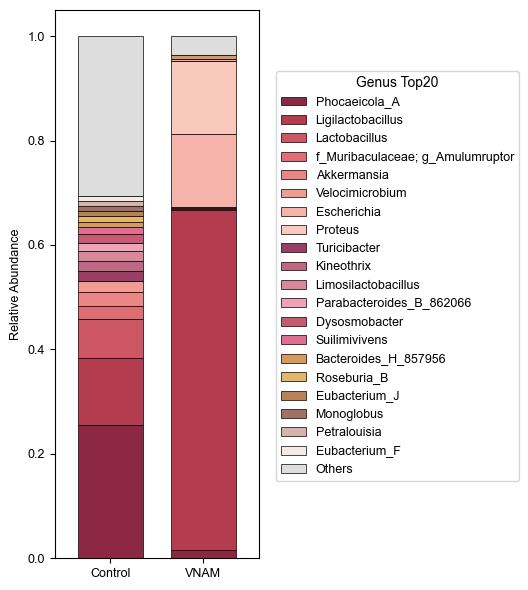

In [24]:
## Genus Level - Top 20

df_barplot.plot(kind='bar', stacked=True,figsize=(5.5, 6), colormap=wine_soft_21, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=9)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=9)  #Edit
plt.title('')
plt.legend(title='Genus Top20', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
#plt.savefig('genus_rel_top20.tiff', dpi=300, bbox_inches='tight')
plt.show()

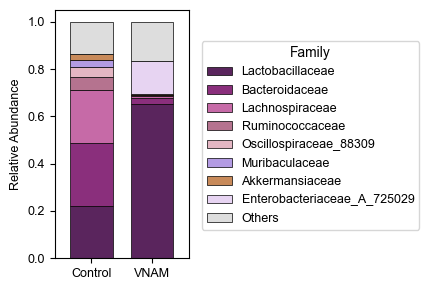

In [25]:
## Family Level

df_barplot2.plot(kind='bar', stacked=True,figsize=(4.5, 3), colormap=darkpurple_axis_rosegold_21, edgecolor='k', linewidth=0.5, width=0.7)
plt.xticks(ticks=range(len(df_barplot2.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=9)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=9)  #Edit
plt.title('')
plt.legend(title='Family', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
#plt.savefig('family_rel_abun_top8.tiff', dpi=300, bbox_inches='tight')
plt.show()

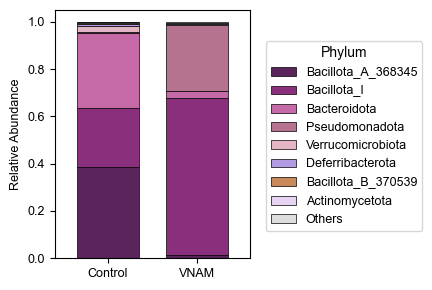

In [26]:
## Phylum Level

df_barplot3.plot(kind='bar', stacked=True,figsize=(4.5, 3), colormap=darkpurple_axis_rosegold_21, edgecolor='k', linewidth=0.5, width=0.7)
plt.xticks(ticks=range(len(df_barplot3.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=9)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=9)  #Edit
plt.title('')
plt.legend(title='Phylum', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
#plt.savefig('phylum_rel_abun_top8.tiff', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
'''
## Genus Level - Top 8

df_barplot.plot(kind='bar', stacked=True,figsize=(4.5, 3), colormap=darkpurple_axis_rosegold_21, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기
plt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=9)  #Edit: plot에 표시될 이름으로 labels 지정
plt.yticks(fontsize=9)
plt.xlabel('')
plt.ylabel('Relative Abundance', fontsize=9)  #Edit
plt.title('')
plt.legend(title='Genus', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정
plt.tight_layout()
plt.savefig('genus_rel_top8.png', dpi=500, bbox_inches='tight')
plt.show()
'''

"\n## Genus Level - Top 8\n\ndf_barplot.plot(kind='bar', stacked=True,figsize=(4.5, 3), colormap=darkpurple_axis_rosegold_21, edgecolor='k', linewidth=0.5, width=0.7)  ## Pastel1은 9개 색 제공 -> 그 이상은 색깔 돌려막기\nplt.xticks(ticks=range(len(df_barplot.index)), labels=['Control', 'VNAM'], rotation=0, fontsize=9)  #Edit: plot에 표시될 이름으로 labels 지정\nplt.yticks(fontsize=9)\nplt.xlabel('')\nplt.ylabel('Relative Abundance', fontsize=9)  #Edit\nplt.title('')\nplt.legend(title='Genus', bbox_to_anchor=(1.05, 0.9), fontsize=9)  #Edit: legend 위치에 맞춰서 조정\nplt.tight_layout()\nplt.savefig('genus_rel_top8.png', dpi=500, bbox_inches='tight')\nplt.show()\n"